# Notebook 2: Exploratory Data Analysis (EDA)

**EDA** means examining data carefully before building any predictive model on top of it. Understand its
shape, spot problems (missing values, weird outliers), and get a feel for the patterns, the same way you'd
skim a document before editing it, rather than diving in blind.

This notebook covers, in order:
1. Checking for missing data across all datasets
2. Understanding claim severity (how much claims cost)
3. Understanding claim causes and geography
4. Confirming the Hurricane Marisol impact matches the storm data
5. A first look at the fraud labels

Every chart and calculation is explained as we go.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A consistent, readable chart style for the whole notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

pd.set_option("display.max_columns", 20)

DATA_DIR = "../04_Datasets/"
policies        = pd.read_csv(DATA_DIR + "01_policies.csv")
claims          = pd.read_csv(DATA_DIR + "02_claims.csv")
weather_zones   = pd.read_csv(DATA_DIR + "03_weather_zone_impact.csv")
fraud_labels    = pd.read_csv(DATA_DIR + "06_fraud_labels.csv")

print("Data loaded. Ready for exploration.")

Data loaded. Ready for exploration.


## 1. Checking for Missing Data

Real-world datasets almost always have gaps: a field nobody filled in, a value not yet available, a
measurement that genuinely doesn't apply. Before doing anything else, we should find out *where* the gaps
are and *why* they might exist, rather than assuming every dataset is complete.

`.isna()` checks each cell in a table and marks it `True` if it's empty (missing) and `False` otherwise.
`.sum()` then adds those up per column, giving us a count of missing values per field.

In [2]:
print("Missing values in Claims:")
print(claims.isna().sum())
print()
print("Missing values in Policies:")
print(policies.isna().sum())

Missing values in Claims:
claim_id                  0
policy_id                 0
date_of_loss              0
date_reported             0
cause_of_loss            17
claim_status              0
is_catastrophe_flag       0
storm_id                862
reported_severity         0
settlement_date        2035
dtype: int64

Missing values in Policies:
policy_id              0
policyholder_name      0
property_address       0
zone_id                0
coastal_zone_flag      0
construction_type      0
year_built             0
coverage_type          0
total_insured_value    0
policy_start_date      0
annual_premium         0
dtype: int64


You should see missing values in `cause_of_loss` (in Claims) and none in Policies. The next step is checking *which*
claims are missing a cause, and whether that absence is random or follows a pattern.

This matters because there are two very different kinds of missing data:
- **Missing at random**: no pattern, safe to mostly ignore or fill with a simple average or placeholder.
- **Missing for a reason**: there's an underlying cause, and understanding it tells you something real
  about the business. This is usually the more interesting and more common case in real insurance data.

In [3]:
# Check the reported dates of claims that are missing a cause_of_loss
missing_cause = claims[claims["cause_of_loss"].isna()]
print(f"Number of claims missing a cause_of_loss: {len(missing_cause)}")
print()
print("Most recent date_reported among ALL claims:", claims["date_reported"].max())
print("date_reported values for claims MISSING a cause:")
print(missing_cause["date_reported"].sort_values(ascending=False).head(10).to_string())

Number of claims missing a cause_of_loss: 17

Most recent date_reported among ALL claims: 2026-08-17
date_reported values for claims MISSING a cause:
1720    2026-08-17
1166    2026-08-17
2558    2026-08-17
998     2026-08-14
1406    2026-08-14
1810    2026-08-13
1241    2026-08-12
2639    2026-08-12
2591    2026-08-12
2481    2026-08-10


You should notice these missing-cause claims cluster around the *most recent* reported dates. That
makes sense: when a claim first comes in, an adjuster hasn't yet had time to fully investigate and classify
exactly what caused the damage. This isn't a data error. It's a snapshot of claims still in their earliest
stage. Knowing this, we would **not** want to delete these rows (real, recent claims would be lost) or fill
them with a random guess. The more honest approach is to leave them as "not yet classified" and revisit once
more information comes in. That's exactly what would happen in a real claims department.

## 2. Understanding Claim Severity

`reported_severity` is the dollar amount of each claim. The next step is visualizing its distribution: how claim amounts are spread out across all claims.

A **histogram** groups values into "bins" (ranges) and shows how many claims fall into each range. It's similar to a bar chart, but for continuous numbers rather than categories.

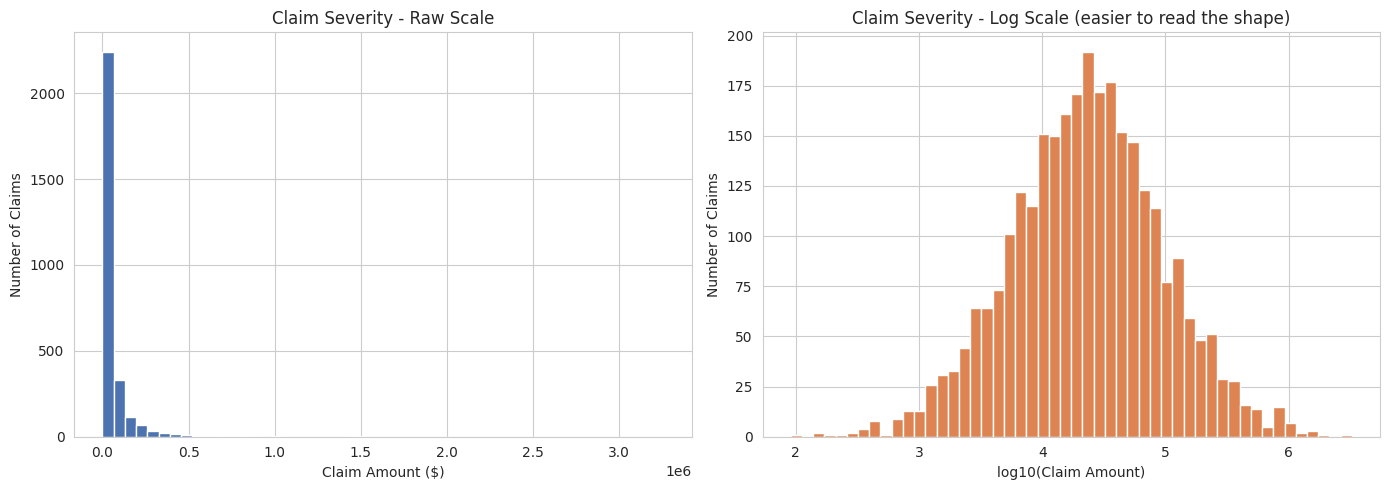

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: the raw severity distribution
axes[0].hist(claims["reported_severity"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Claim Severity - Raw Scale")
axes[0].set_xlabel("Claim Amount ($)")
axes[0].set_ylabel("Number of Claims")

# Right chart: the same data, but on a "log scale" x-axis.
# A log scale compresses large numbers, which makes it much easier to see the
# shape of a distribution when a few values are far larger than the rest.
axes[1].hist(np.log10(claims["reported_severity"]), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_title("Claim Severity - Log Scale (easier to read the shape)")
axes[1].set_xlabel("log10(Claim Amount)")
axes[1].set_ylabel("Number of Claims")

plt.tight_layout()
plt.savefig("outputs_severity_distribution.png", dpi=120)
plt.show()

On the raw scale (left), almost every claim looks squashed near zero because a small number of very
large claims stretch the x-axis out. This is the "long tail" we mentioned in Notebook 1. On the log scale
(right), the shape becomes much easier to read. Most claims cluster in a fairly predictable range, with a
tail of larger ones.

This pattern (many small values, a few very large ones) is called a **right-skewed distribution**, and it's
extremely common for money-related data: claim costs, hospital bills, home prices, etc. It's also *why*
plain averages can be misleading for this kind of data. That's exactly what we saw in Notebook 1, where the
mean was noticeably higher than the median.

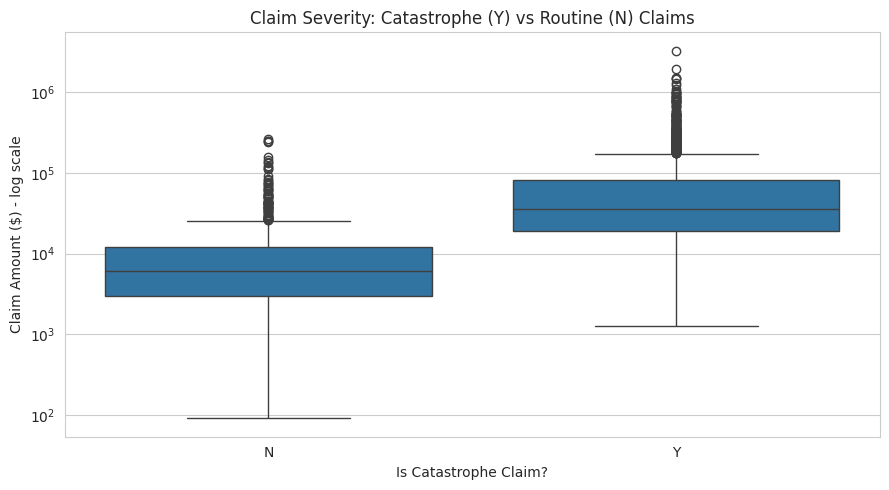

                      count          mean            std      min       25%  \
is_catastrophe_flag                                                           
N                     862.0  12257.261566   23509.335353    90.87   2995.37   
Y                    2021.0  83126.789550  162399.568240  1256.84  18774.92   

                           50%         75%         max  
is_catastrophe_flag                                     
N                     6089.455  12186.5225   265441.56  
Y                    35910.060  80565.3900  3258045.00  


In [5]:
# Compare catastrophe claims vs routine claims side-by-side
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=claims, x="is_catastrophe_flag", y="reported_severity", ax=ax)
ax.set_yscale("log")
ax.set_title("Claim Severity: Catastrophe (Y) vs Routine (N) Claims")
ax.set_xlabel("Is Catastrophe Claim?")
ax.set_ylabel("Claim Amount ($) - log scale")
plt.tight_layout()
plt.savefig("outputs_severity_by_cat_flag.png", dpi=120)
plt.show()

print(claims.groupby("is_catastrophe_flag")["reported_severity"].describe())

A **boxplot** summarizes a distribution with a box (the middle 50% of values) and a line through the
middle (the median), plus individual dots for unusually extreme values ("outliers"). You should see that
catastrophe claims tend to run notably higher than routine claims, which makes sense since a hurricane causes
more severe damage than an average, everyday claim.

## 3. Claim Causes and Geography

The next step examines what is causing these claims, and where.

cause_of_loss
Wind                        1110
Wind + Flood                 512
Flood/Storm Surge            382
Other Weather                163
Fire                         162
Liability                    137
Theft                        137
Vandalism                    122
Water Damage (Non-Storm)     120
Falling Tree (Non-Storm)       7
Lightning Strike               6
Sinkhole                       4
Frozen Pipe Burst              4
Name: count, dtype: int64


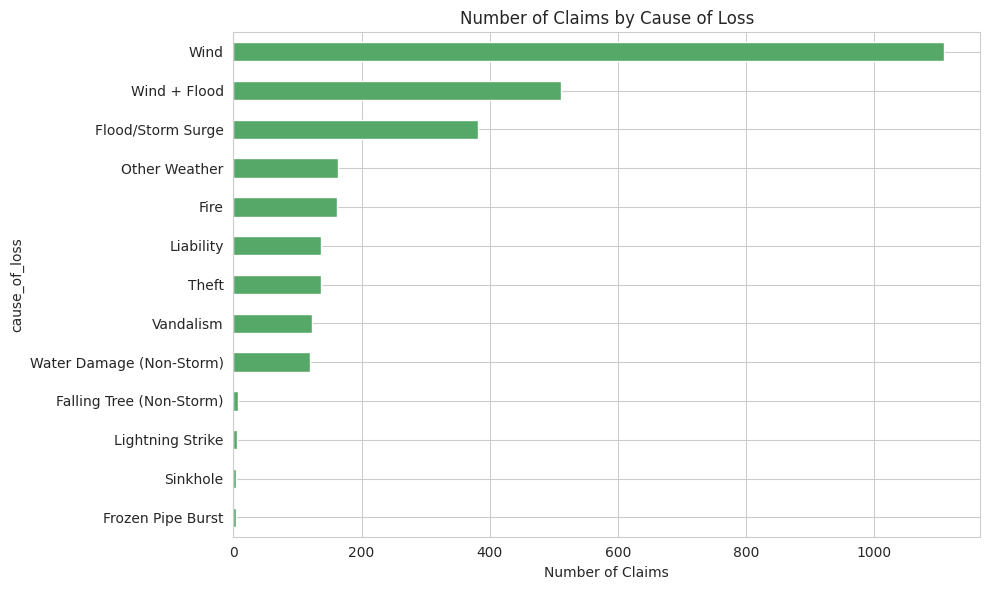

In [6]:
cause_counts = claims["cause_of_loss"].value_counts()
print(cause_counts)

fig, ax = plt.subplots(figsize=(10, 6))
cause_counts.plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Number of Claims by Cause of Loss")
ax.set_xlabel("Number of Claims")
ax.invert_yaxis()  # largest bar on top
plt.tight_layout()
plt.savefig("outputs_cause_of_loss.png", dpi=120)
plt.show()

Notice the long tail here too, in a *categorical* (non-numeric) form: a few common causes (Wind,
Wind + Flood, Flood/Storm Surge) dominate, while several rare causes (Sinkhole, Lightning Strike, Frozen
Pipe Burst) each have only a handful of claims. When we build predictive models later, these rare categories
can be tricky: a model has very few examples to learn from for something like "Sinkhole," so we'll need to
be thoughtful about how we handle them rather than treating every category equally.

In [7]:
# Now let's connect claims back to policies, so we can see claims by geographic zone.
# merge() joins two tables together based on a shared column - here, policy_id.
# Think of this like a VLOOKUP in Excel, or a JOIN if you've used SQL before.

claims_with_zone = claims.merge(policies[["policy_id", "zone_id", "coastal_zone_flag"]], on="policy_id")

claims_per_zone = claims_with_zone["zone_id"].value_counts().sort_index()
policies_per_zone = policies["zone_id"].value_counts().sort_index()

# Claim RATE (claims / policies in that zone) is more meaningful than a raw claim count,
# since zones don't all have the same number of policies to begin with.
claim_rate_per_zone = (claims_per_zone / policies_per_zone * 100).round(1)

comparison = pd.DataFrame({
    "policies": policies_per_zone,
    "claims": claims_per_zone,
    "claim_rate_pct": claim_rate_per_zone
})
print(comparison)

         policies  claims  claim_rate_pct
zone_id                                  
Z1           1102     881            79.9
Z2            957     808            84.4
Z3            902     594            65.9
Z4            729     248            34.0
Z5            626     188            30.0
Z6            684     164            24.0


## 4. Confirming the Hurricane Marisol Impact

In Notebook 1, Marsh Point (Z2) showed the strongest winds and highest storm surge. The claim rate table above
can be checked against that observation: do the zones hit hardest by wind and surge show the
highest claim rates?

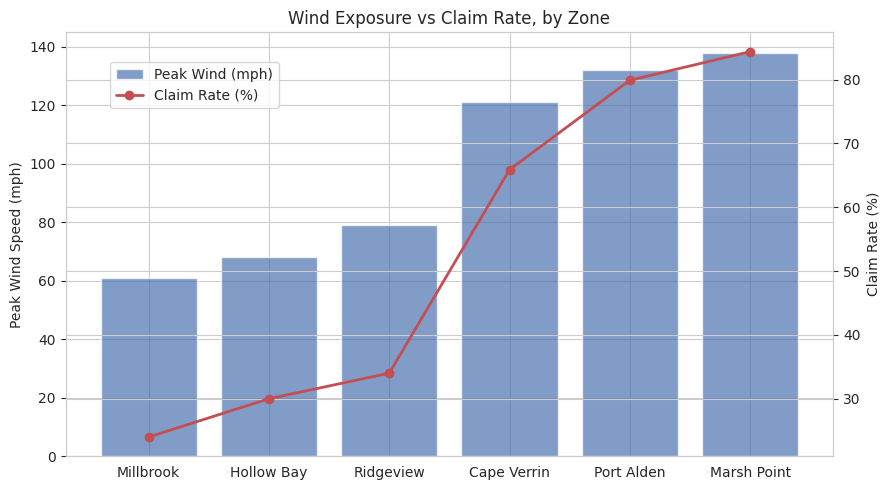

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
merged = weather_zones.merge(comparison, on="zone_id")
merged = merged.sort_values("peak_wind_experienced_mph")

ax2 = ax.twinx()  # a second y-axis sharing the same x-axis, so we can compare two different scales
ax.bar(merged["zone_name"], merged["peak_wind_experienced_mph"], color="#4C72B0", alpha=0.7, label="Peak Wind (mph)")
ax2.plot(merged["zone_name"], merged["claim_rate_pct"], color="#C44E52", marker="o", linewidth=2, label="Claim Rate (%)")

ax.set_ylabel("Peak Wind Speed (mph)")
ax2.set_ylabel("Claim Rate (%)")
ax.set_title("Wind Exposure vs Claim Rate, by Zone")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig("outputs_wind_vs_claimrate.png", dpi=120)
plt.show()

You should see the bars (wind speed) and the line (claim rate) rise and fall together: zones with
higher peak wind experienced noticeably higher claim rates. This is a good sanity check: it confirms our
data behaves the way we'd expect a real hurricane's damage pattern to behave, which gives us confidence to
build predictive models on top of it in the next notebooks.

## 5. A First Look at Fraud Labels

Recall from Notebook 1 that not every claim has been investigated yet for fraud. The next cell quantifies that.

In [9]:
print("Fraud label breakdown (including claims not yet investigated):")
print(fraud_labels["is_fraud"].value_counts(dropna=False))

investigated = fraud_labels.dropna(subset=["is_fraud"])
fraud_rate = investigated["is_fraud"].mean() * 100
print(f"\nOf claims that HAVE been investigated, {fraud_rate:.1f}% were flagged as fraudulent.")
print(f"({len(investigated)} of {len(fraud_labels)} total claims have been investigated so far.)")

Fraud label breakdown (including claims not yet investigated):
is_fraud
0.0    1408
NaN    1227
1.0     248
Name: count, dtype: int64

Of claims that HAVE been investigated, 15.0% were flagged as fraudulent.
(1656 of 2883 total claims have been investigated so far.)


Two things worth noticing:
1. Most claims (`NaN` in `is_fraud`) haven't been investigated yet. This is realistic since investigation takes
   time and resources, but it also means we only have full information on a subset of claims to learn from.
2. Among investigated claims, a noticeably higher share are fraud than you might expect from
   everyday experience. This matches real industry research showing fraud tends to increase after major
   catastrophes (more claims, more opportunity, harder to investigate everything quickly).

This "some labels are missing, and the classes are imbalanced" situation is exactly the challenge we'll
tackle head-on in Notebook 4 (Fraud Detection).

## Summary

Key takeaways to carry into the next notebooks:

1. Missing data in this module usually has a *reason*. Investigate before deciding what to do about it.
2. Claim severity is right-skewed (long tail): a few large claims, many smaller ones. This affects how we
   should model and evaluate severity predictions in Notebook 3.
3. Claims by cause of loss are also long-tailed: a few common causes, several rare ones.
4. The geographic claim pattern lines up with the actual storm's wind/surge data. The dataset behaves
   realistically.
5. Fraud labels are incomplete and imbalanced, which is something we'll need specific techniques to handle well.

**Next:** Open `03_Prediction.ipynb` to start building models that predict how much a claim will cost.